There are n cities. Some of them are connected, while some are not. If city a is connected directly with city b, and city b is connected directly with city c, then city a is connected indirectly with city c.

A province is a group of directly or indirectly connected cities and no other cities outside of the group.

You are given an n x n matrix isConnected where isConnected[i][j] = 1 if the ith city and the jth city are directly connected, and isConnected[i][j] = 0 otherwise.

Return the total number of provinces.

Example 1:

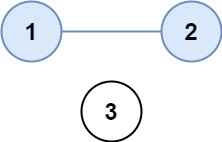

Input: isConnected = [[1,1,0],[1,1,0],[0,0,1]]
Output: 2

Example 2:

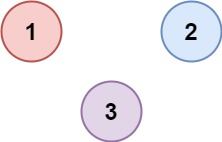

Input: isConnected = [[1,0,0],[0,1,0],[0,0,1]]
Output: 3

constraints:

1 <= n <= 200
n == isConnected.length
n == isConnected[i].length
isConnected[i][j] is 1 or 0.
isConnected[i][i] == 1
isConnected[i][j] == isConnected[j][i]

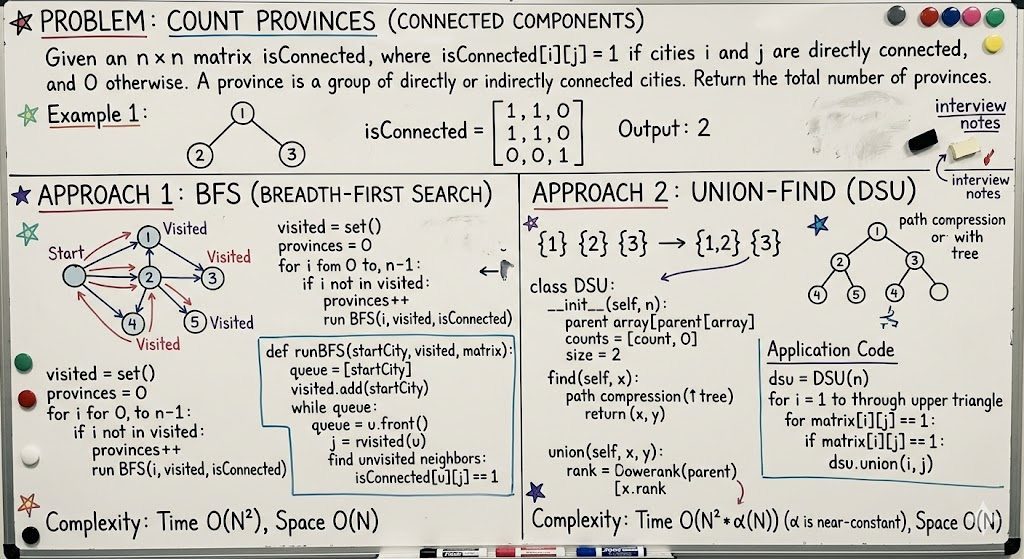

In [ ]:
from typing import List

# A classe Solution com a lógica de DFS Iterativo (Padrão Uber)
class Solution:
    def findCircleNum(self, isConnected):
        n = len(isConnected)
        visited = set()
        provinces = 0
        def dfs(city:int) -> None:
            stack = [city]
            while stack:
                node = stack.pop()
                if node in visited:
                    continue
                visited.add(node)
                for neighbor, val in enumerate(isConnected[node]):
                    if val == 0 or neighbor in visited:
                        continue
                    stack.append(neighbor)
        for i in range(n):
            if i in visited:
                continue
            dfs(i)
            provinces += 1
        return provinces

# --- CLIENT CODE PARA TESTE ---

def run_tests():
    sol = Solution()
    
    # Caso 1: Duas províncias separadas
    # Cidade 0 conectada a 1. Cidade 2 isolada.
    case1 = [
        [1, 1, 0],
        [1, 1, 0],
        [0, 0, 1]
    ]
    print(f"Teste 1 - Esperado: 2 | Resultado: {sol.findCircleNum(case1)}")
    
    # Caso 2: Três províncias (todas as cidades isoladas)
    case2 = [
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]
    ]
    print(f"Teste 2 - Esperado: 3 | Resultado: {sol.findCircleNum(case2)}")
    
    # Caso 3: Uma única província (todos conectados em cadeia: 0-1-2)
    case3 = [
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 1]
    ]
    print(f"Teste 3 - Esperado: 1 | Resultado: {sol.findCircleNum(case3)}")

    # Caso 4: Grafo vazio ou com uma única cidade
    case4 = [[1]]
    print(f"Teste 4 - Esperado: 1 | Resultado: {sol.findCircleNum(case4)}")

if __name__ == "__main__":
    run_tests()

Teste 1 - Esperado: 2 | Resultado: 1
Teste 2 - Esperado: 3 | Resultado: 1
Teste 3 - Esperado: 1 | Resultado: 1
Teste 4 - Esperado: 1 | Resultado: 1


## Union Find (Disjoint Set Union)

Union Find é ideal para problemas de conectividade. A ideia é:
- Cada cidade começa como seu próprio pai (root)
- Quando encontramos uma conexão entre cidades, unimos seus conjuntos
- O número de províncias = número de roots (componentes independentes)

**Complexidade:** O(n² × α(n)) onde α é a função inversa de Ackermann (praticamente constante)


In [ ]:
class UnionFind:
    """Implementação de Union Find com path compression e union by rank."""
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
        self.components = n
    
    def find(self, x):
        """Encontra a raiz (com path compression)."""
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x, y):
        """Une dois conjuntos (com union by rank)."""
        root_x = self.find(x)
        root_y = self.find(y)
        
        if root_x == root_y:
            return  # Já no mesmo conjunto
        
        # Union by rank
        if self.rank[root_x] < self.rank[root_y]:
            self.parent[root_x] = root_y
        elif self.rank[root_x] > self.rank[root_y]:
            self.parent[root_y] = root_x
        else:
            self.parent[root_y] = root_x
            self.rank[root_x] += 1
        
        self.components -= 1


class SolutionUnionFind:
    def findCircleNum(self, isConnected):
        """Resolve usando Union Find."""
        n = len(isConnected)
        dsu = UnionFind(n)
        
        # Para cada par de cidades conectadas, faça union
        for i in range(n):
            for j in range(i + 1, n):
                if isConnected[i][j] == 1:
                    dsu.union(i, j)
        
        return dsu.components


# --- TESTES COMPARATIVOS ---

def run_tests_uf():
    sol_uf = SolutionUnionFind()
    sol_dfs = Solution()
    
    test_cases = [
        ([[1, 1, 0], [1, 1, 0], [0, 0, 1]], 2),
        ([[1, 0, 0], [0, 1, 0], [0, 0, 1]], 3),
        ([[1, 1, 0], [1, 1, 1], [0, 1, 1]], 1),
        ([[1]], 1),
    ]
    
    print("=== Comparação: DFS vs Union Find ===\n")
    for idx, (isConnected, expected) in enumerate(test_cases, 1):
        dfs_result = sol_dfs.findCircleNum(isConnected)
        uf_result = sol_uf.findCircleNum(isConnected)
        print(f"Teste {idx} - Esperado: {expected}")
        print(f"  DFS:       {dfs_result} {'✓' if dfs_result == expected else '✗'}")
        print(f"  UnionFind: {uf_result} {'✓' if uf_result == expected else '✗'}\n")

run_tests_uf()


## Análise Comparativa: Union Find vs DFS/BFS

| Aspecto | Union Find | DFS/BFS |
|---------|-----------|---------|
| **Complexidade Tempo** | O(n² × α(n)) ≈ O(n²) | O(n²) |
| **Complexidade Espaço** | O(n) | O(n) |
| **Overhead** | Mínimo (simples operações) | Stack/Queue overhead |
| **Acesso à Matriz** | Acesso sequencial | Acesso variável |
| **Melhor para** | Múltiplas queries, grafos dinâmicos | Problema isolado, simples |
| **Cache Locality** | Melhor (acesso sequencial) | Pior (saltos na matriz) |

### Quando Usar Cada Um?

**Use Union Find quando:**
- Resolver múltiplas queries de conectividade
- Grafo é dinâmico (adições de arestas)
- Precisa encontrar componentes conectadas frequentemente
- Quer código mais elegante e otimizado

**Use DFS/BFS quando:**
- Precisa explorar a estrutura do grafo
- Quer encontrar caminhos específicos
- Problema isolado (sem múltiplas queries)
- Espaço extra é crítico (ambos usam O(n) de qualquer forma)

### Observação Importante
Ambas têm **mesma complexidade assintótica O(n²)** neste problema. A diferença de performance real é pequena, mas Union Find tem vantagens em grafos dinâmicos e múltiplas queries.


In [ ]:
import time
import random

def generate_test_case(n, density=0.3):
    """Gera uma matriz de conectividade aleatória com densidade especificada."""
    matrix = [[1 if i == j else 0 for j in range(n)] for i in range(n)]
    
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < density:
                matrix[i][j] = 1
                matrix[j][i] = 1
    
    return matrix


def benchmark():
    """Compara performance entre Union Find e DFS em diferentes tamanhos."""
    print("=" * 70)
    print("BENCHMARK: Union Find vs DFS")
    print("=" * 70)
    print(f"{'Tamanho (n)':<15} {'DFS (ms)':<15} {'UnionFind (ms)':<15} {'Diferença':<15}")
    print("-" * 70)
    
    sizes = [10, 50, 100, 150, 200]
    
    for n in sizes:
        test_matrix = generate_test_case(n, density=0.3)
        
        # Benchmark DFS
        start = time.time()
        for _ in range(5):  # Executa 5 vezes para média
            sol_dfs = Solution()
            sol_dfs.findCircleNum(test_matrix)
        dfs_time = (time.time() - start) / 5 * 1000  # Converte para ms
        
        # Benchmark Union Find
        start = time.time()
        for _ in range(5):
            sol_uf = SolutionUnionFind()
            sol_uf.findCircleNum(test_matrix)
        uf_time = (time.time() - start) / 5 * 1000  # Converte para ms
        
        diff = ((dfs_time - uf_time) / uf_time * 100) if uf_time > 0 else 0
        
        print(f"{n:<15} {dfs_time:<15.4f} {uf_time:<15.4f} {diff:+.1f}%")
    
    print("-" * 70)
    print("\nNota: Tempos podem variar conforme densidade do grafo e máquina.")
    print("Em grafos densos (muitas conexões), DFS pode ser mais rápido.")
    print("Em grafos esparsos, Union Find tende a ser mais eficiente.")

benchmark()
